<a href="https://colab.research.google.com/github/konstantinosPapado/Reinforcement-Learning-Gym/blob/main/Reinforcement_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exercise 9. Reinforcement Learning

First, we install all the needed libraries.

In [2]:
!pip install swig

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 24.0 MB/s eta 0:00:00


In [3]:
!pip install gymnasium[box2d]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 37.7 MB/s eta 0:00:00


In [4]:
!pip install renderlab

In [5]:
!pip install rllib

In [13]:
!pip install stable_baselines3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 4.2 MB/s eta 0:00:00


Import libraries

In [14]:
import gymnasium as gym
import renderlab
import rllib
import swig
import numpy as np
import random
from stable_baselines3 import DQN, PPO
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt
import pandas as pd
import os

  return datetime.utcnow().replace(tzinfo=utc)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Creation of the enviroment.

In [8]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")
env = renderlab.RenderFrame(env, "./output_random")

Step: This function executes an action in the enviroment.
Reset: This function is used for reseting the enviroment, or when the enviroment is first created.
Render: This function is used for visualizing the enviroment.

Lunar Lander V3:
Observation Space: The state is an 8-dimensional vector: the coordinates of the lander in x & y, its linear velocities in x & y, its angle, its angular velocity, and two booleans that represent whether each leg is in contact with the ground or not.
Action Space: is Discrete and has 4 available values (Do nothing, Fire left orientation engine, Fire main engine, Fire right orientation engine)
Reward Function:After every step a reward is granted. The total reward of an episode is the sum of the rewards for all the steps within that episode.
For each step, the reward:
is increased/decreased the closer/further the lander is to the landing pad.
is increased/decreased the slower/faster the lander is moving.
is decreased the more the lander is tilted (angle not horizontal).
is increased by 10 points for each leg that is in contact with the ground.
is decreased by 0.03 points each frame a side engine is firing.
is decreased by 0.3 points each frame the main engine is firing.
The episode receive an additional reward of -100 or +100 points for crashing or landing safely respectively.
An episode is considered a solution if it scores at least 200 points.

In [9]:
scores = []

Random Agent.

In [16]:
for episode in range(5):
  observation,info = env.reset()
  done = False
  score = 0
  while not done:
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    score += reward
    done = terminated or truncated
  scores.append(score)
env.play()
mean_score = np.mean(scores)
print(f"Mean Score: {mean_score}")

Moviepy - Building video temp-{start}.mp4.
Moviepy - Writing video temp-{start}.mp4



Moviepy - Done !
Moviepy - video ready temp-{start}.mp4


Mean Score: -171.3571903596238


DQN and PPO.

Setting enviroments for DQN and PPO.

In [17]:
env_dqn = Monitor(gym.make("LunarLander-v3"))
env_ppo = Monitor(gym.make("LunarLander-v3"))

Setting number of steps.

In [18]:
steps = 50000

In [19]:
model_dqn = DQN("MlpPolicy", env_dqn, verbose=1)
model_dqn.learn(total_timesteps=steps)

Using cpu device
Wrapping the env in a DummyVecEnv.


  return datetime.utcnow().replace(tzinfo=utc)



----------------------------------
| rollout/            |          |
|    ep_len_mean      | 80.2     |
|    ep_rew_mean      | -271     |
|    exploration_rate | 0.939    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 620      |
|    time_elapsed     | 0        |
|    total_timesteps  | 321      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 1.49     |
|    n_updates        | 55       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 81.6     |
|    ep_rew_mean      | -204     |
|    exploration_rate | 0.876    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 747      |
|    time_elapsed     | 0        |
|    total_timesteps  | 653      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 1.35     |
|    n_updates      

In [20]:
model_ppo = PPO("MlpPolicy", env_ppo, verbose=1)
model_ppo.learn(total_timesteps=steps)

Using cpu device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 97.9     |
|    ep_rew_mean     | -234     |
| time/              |          |
|    fps             | 1046     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 96          |
|    ep_rew_mean          | -201        |
| time/                   |             |
|    fps                  | 779         |
|    iterations           | 2           |
|    time_elapsed         | 5           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.003584498 |
|    clip_fraction        | 0.00854     |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.38       |
|    explained_varia

In [26]:
env = gym.make("LunarLander-v3")
rewards = []
for ep in range(5):
    obs, _ = env.reset()
    done = False
    ep_reward = 0
    while not done:
        action, _ = model_dqn.predict(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        ep_reward += reward
        done = terminated or truncated
    rewards.append(ep_reward)
mean_dqn = np.mean(rewards)
print(mean_dqn)

-58.94891586312256


In [25]:
env = gym.make("LunarLander-v3")
rewards = []
for ep in range(5):
    obs, _ = env.reset()
    done = False
    ep_reward = 0
    while not done:
        action, _ = model_ppo.predict(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        ep_reward += reward
        done = terminated or truncated
    rewards.append(ep_reward)
mean_ppo = np.mean(rewards)
print(mean_ppo)

-13.829205256746707


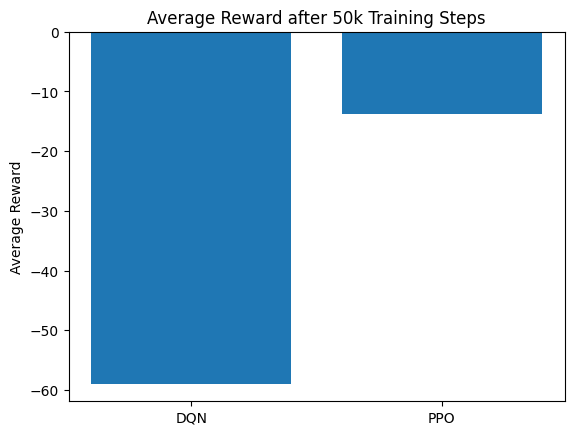

In [27]:
algorithms = ['DQN', 'PPO']
scores = [mean_dqn, mean_ppo]
plt.bar(algorithms, scores)
plt.title('Average Reward after 50k Training Steps')
plt.ylabel('Average Reward')
plt.show()

We see that our models perform better that the random agent.

Best parameters.

In [28]:
model_dqn_tuned = DQN(
    "MlpPolicy",
    gym.make("LunarLander-v3"),
    learning_rate=1e-3,
    buffer_size=50000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    target_update_interval=250,
    exploration_fraction=0.1,
    exploration_final_eps=0.05,
    verbose=1
)

model_ppo_tuned = PPO(
    "MlpPolicy",
    gym.make("LunarLander-v3"),
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=64,
    n_epochs=10,
    gamma=0.999,
    gae_lambda=0.98,
    ent_coef=0.01,
    verbose=1
)

train_steps = 100000
model_dqn_tuned.learn(total_timesteps=train_steps)
model_ppo_tuned.learn(total_timesteps=train_steps)

env = gym.make("LunarLander-v3")
rewards = []
for ep in range(10):
    obs, _ = env.reset()
    done = False
    ep_reward = 0
    while not done:
        action, _ = model_dqn_tuned.predict(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        ep_reward += reward
        done = terminated or truncated
    rewards.append(ep_reward)
mean_dqn_tuned= np.mean(rewards)

env = gym.make("LunarLander-v3")
rewards = []
for ep in range(10):
    obs, _ = env.reset()
    done = False
    ep_reward = 0
    while not done:
        action, _ = model_ppo_tuned.predict(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        ep_reward += reward
        done = terminated or truncated
    rewards.append(ep_reward)
mean_ppo_tuned= np.mean(rewards)

print(f"DQN : {mean_dqn_tuned}")
print(f"PPO : {mean_ppo_tuned}")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 93       |
|    ep_rew_mean      | -126     |
|    exploration_rate | 0.965    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 5342     |
|    time_elapsed     | 0        |
|    total_timesteps  | 372      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 91.4     |
|    ep_rew_mean      | -209     |
|    exploration_rate | 0.931    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 5286     |
|    time_elapsed     | 0        |
|    total_timesteps  | 731      |
----------------------------------
----------------------------------
| rollo

PPO appears to be the superior model, based on our results.